## Librerías

In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

## Base de Datos

In [2]:
data = 'Main Databases/new_master.hdf5'

100%|██████████| 12/12 [03:16<00:00, 16.38s/it]


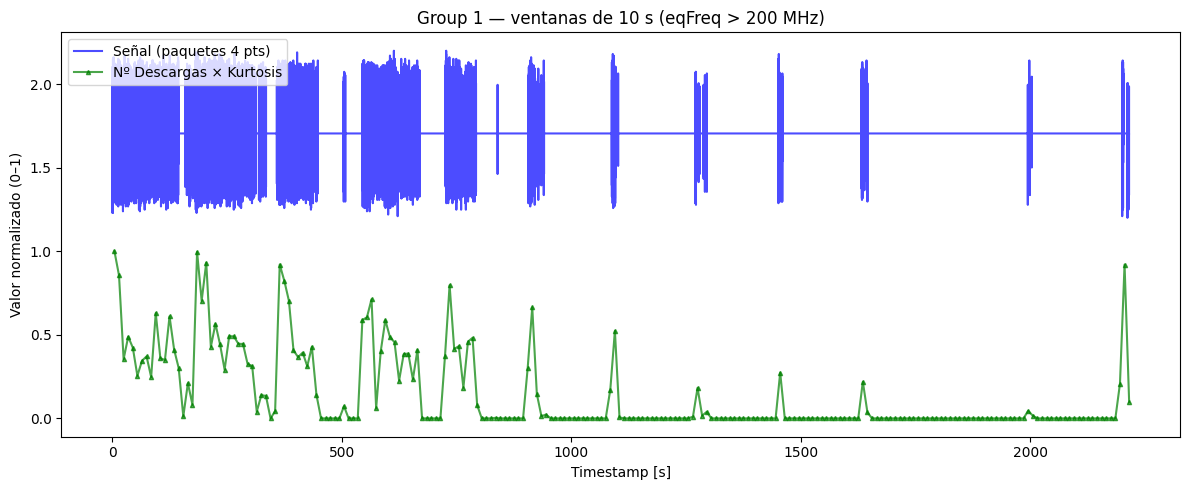

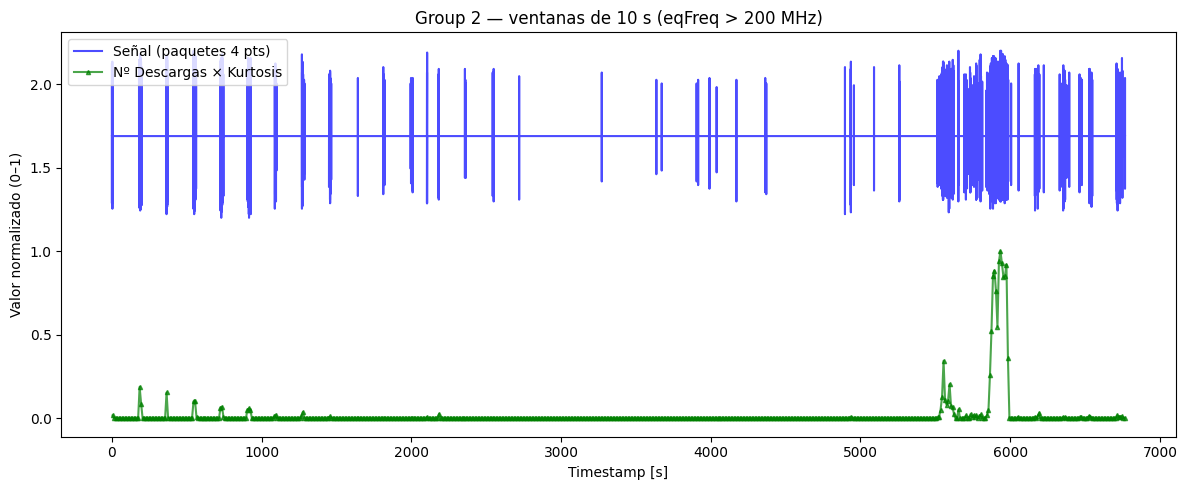

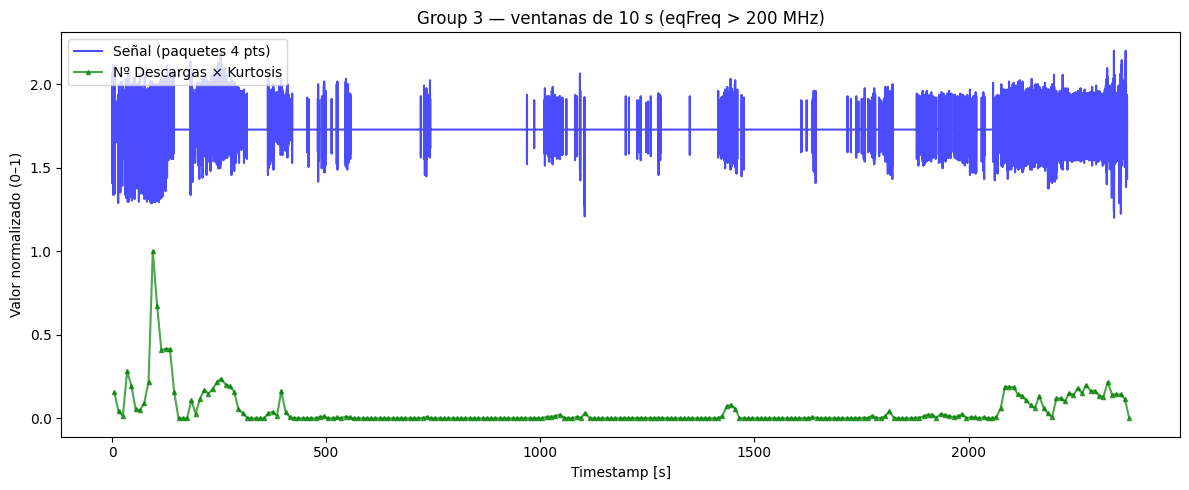

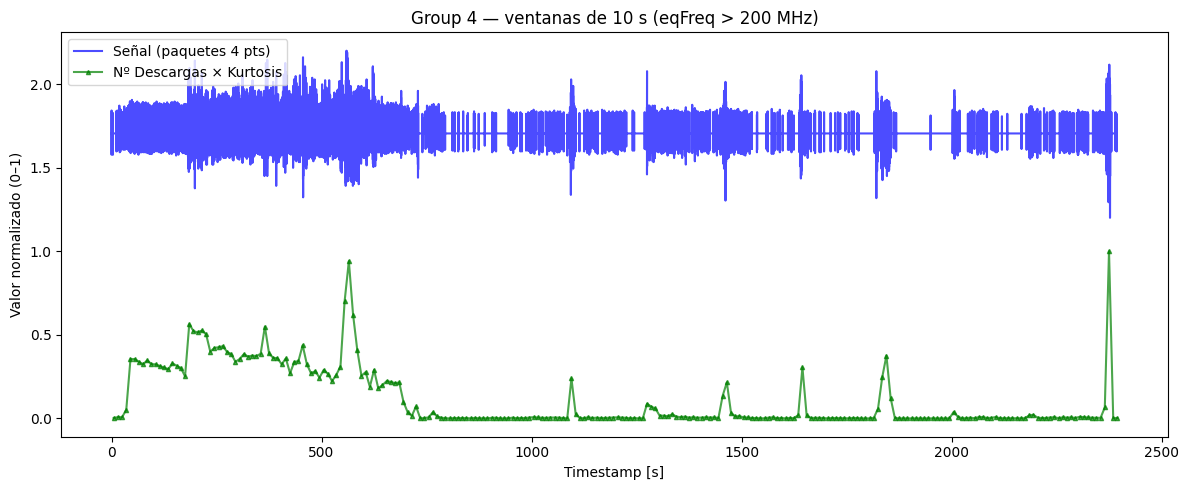

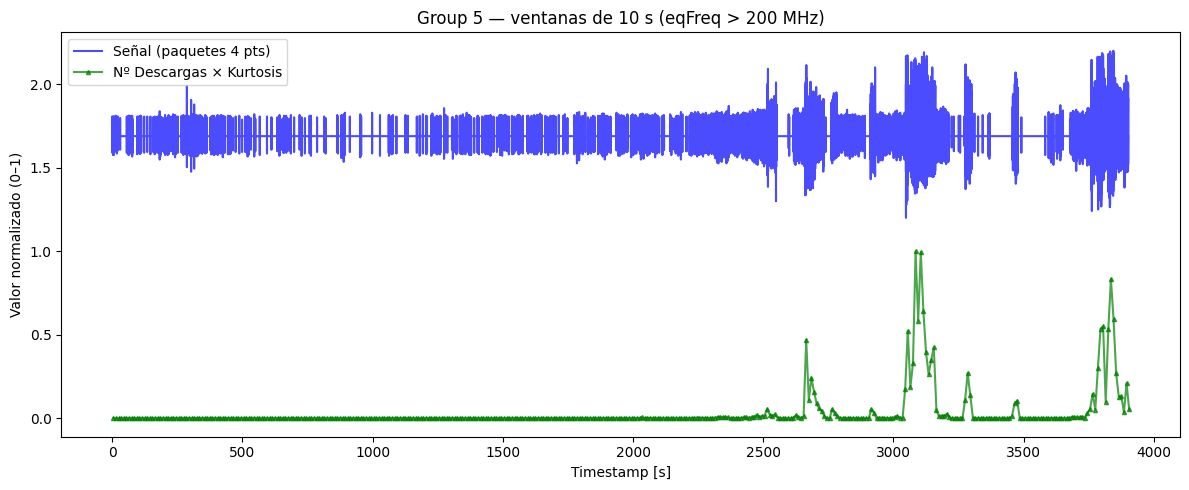

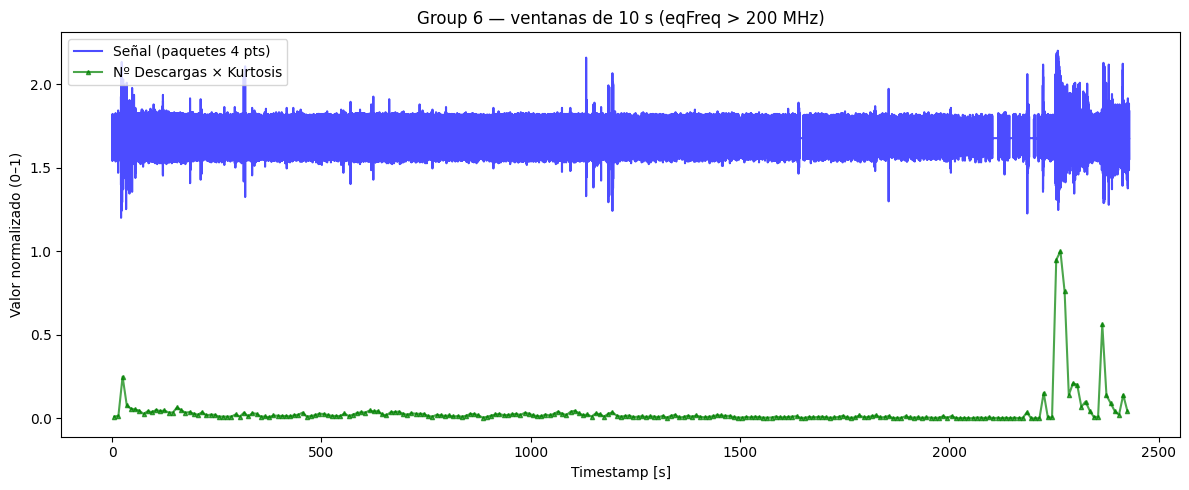

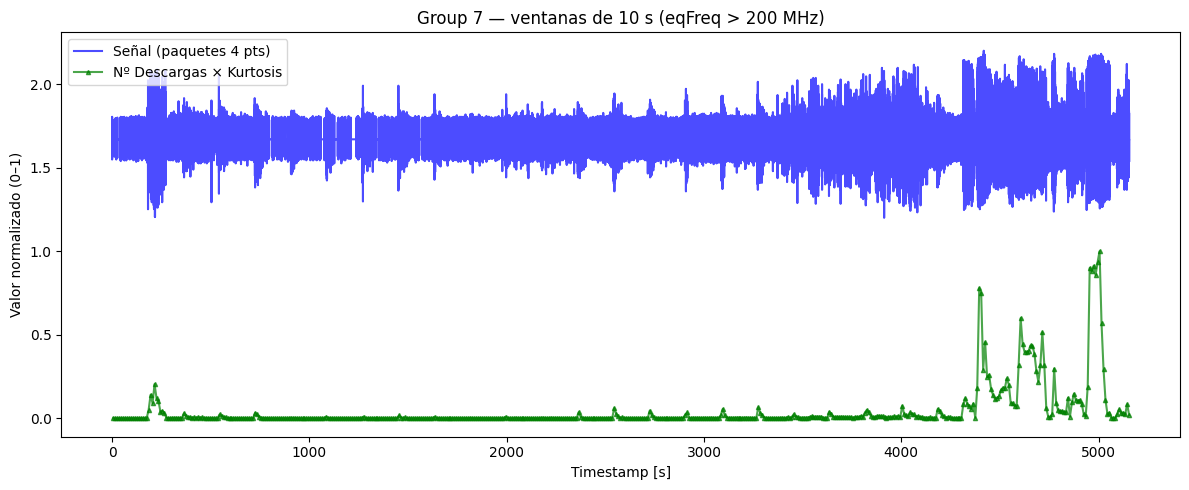

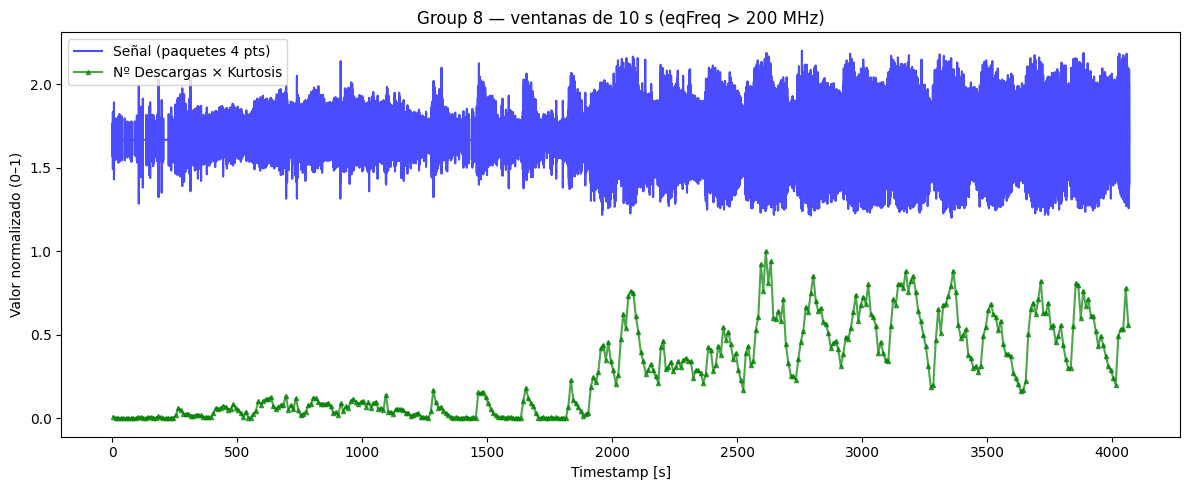

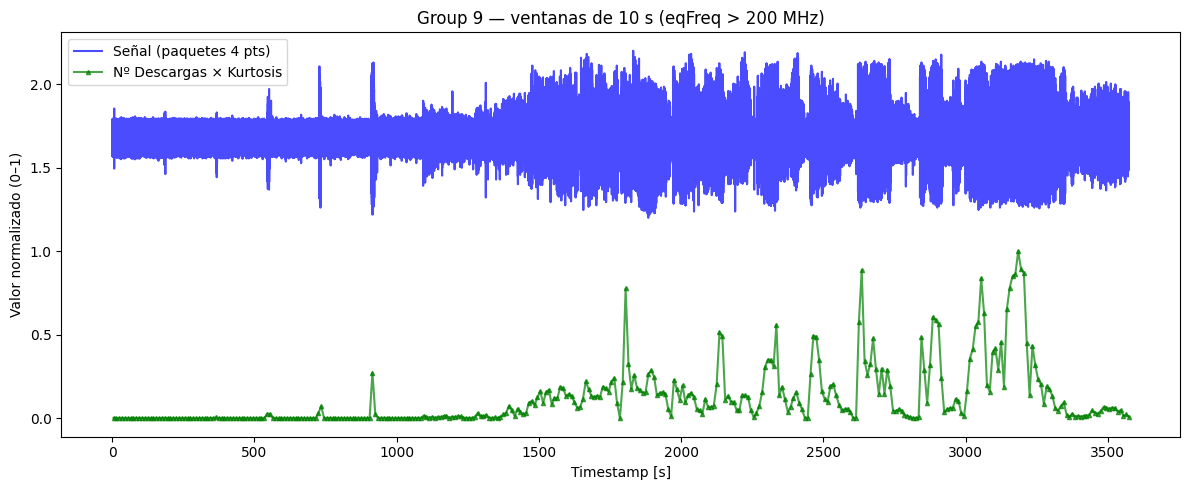

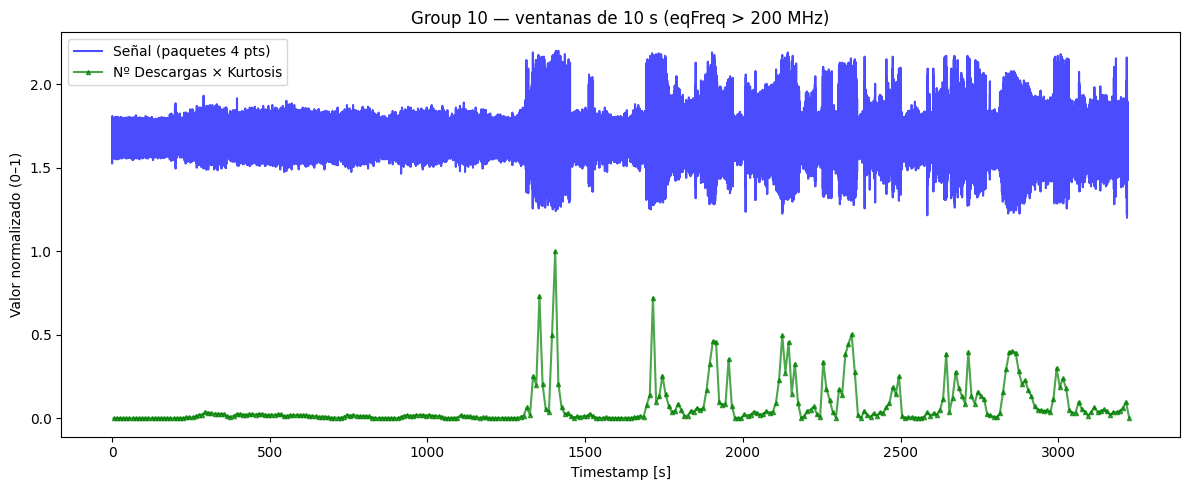

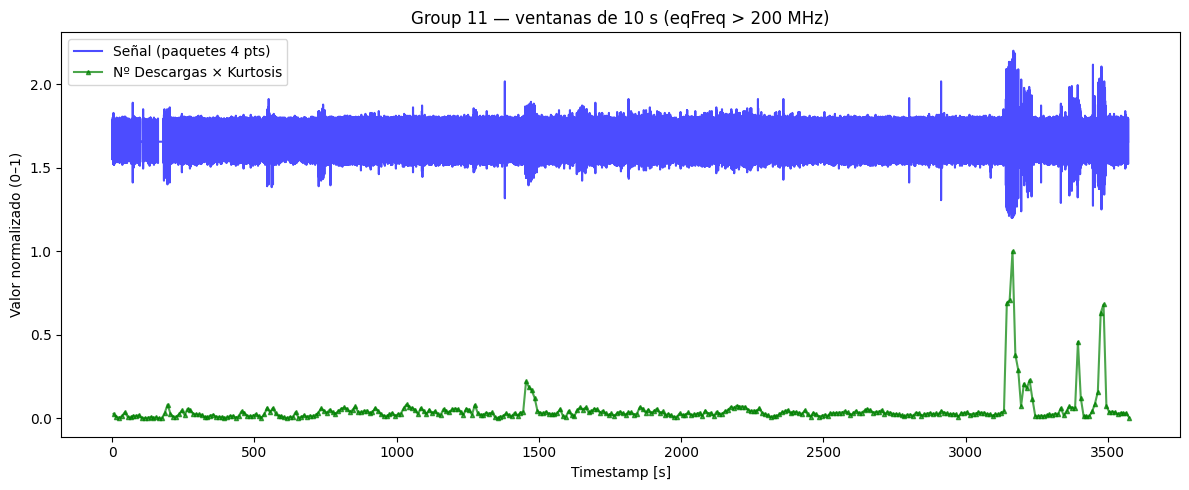

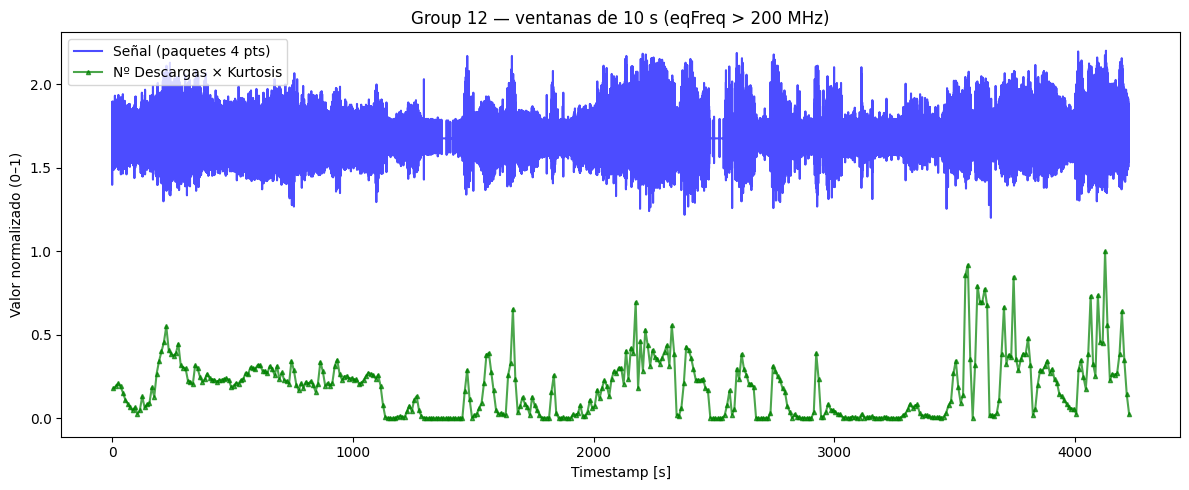

In [ ]:

from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

kurtosis   = []
timestamps = []
eqFreq     = []
vpp        = []
energy     = []
signals    = []  # lista de listas: signals[i] = lista de arrays para el grupo i

with h5py.File(data, 'r') as f:
    groups = (list(f))[-12:]
    for group in tqdm(groups):
        kurtosis.append(f[group]['Metrics']['kurtosis'][()])
        timestamps.append(f[group]['Metrics']['timestamp'][()])
        eqFreq.append(f[group]['Metrics']['eqFreq'][()])
        vpp.append(f[group]['Metrics']['vpp'][()])
        energy.append(f[group]['Metrics']['energy'][()])
        sgn_names = list(f[group]['Signals'])
        grp_signals = []
        for sgn in sgn_names:
            grp_signals.append(f[group]['Signals'][sgn][()])
        signals.append(grp_signals)

WINDOW_SIZE   = 10       # segundos
MAX_POINTS    = 1000
SIGNAL_DUR    = 1e-6     # 1 µs por señal
N_SAMPLES     = 3000     # muestras por señal

def build_pulse_series(filtered_timestamps, grp_signals, grp_mask):
    """
    Para cada timestamp filtrado, toma su señal correspondiente y genera
    4 puntos: (t0, 0), (t_max, max), (t_min, min), (t_end, 0).
    Devuelve arrays t_pulse, v_pulse listos para graficar.
    """
    dt_sample = SIGNAL_DUR / N_SAMPLES
    original_indices = np.where(grp_mask)[0]  # índices en el array original

    t_all = []
    v_all = []

    for k, orig_idx in enumerate(original_indices):
        t0  = filtered_timestamps[k]
        sig = grp_signals[orig_idx]

        i_max = np.argmax(sig)
        i_min = np.argmin(sig)
        v_max = sig[i_max]
        v_min = sig[i_min]

        t_max = t0 + i_max * dt_sample
        t_min = t0 + i_min * dt_sample
        t_end = t0 + SIGNAL_DUR

        # Los 4 puntos, ordenados por tiempo
        pts = sorted([(t0, 0.0), (t_max, v_max), (t_min, v_min), (t_end, 0.0)],
                     key=lambda x: x[0])

        for t_val, v_val in pts:
            t_all.append(t_val)
            v_all.append(v_val)

    return np.array(t_all), np.array(v_all)


for i in range(len(kurtosis)):

    mask = (eqFreq[i] > 200e6) & (vpp[i] < 0.28)
    filtered_timestamps = timestamps[i][mask]
    filtered_kurtosis   = kurtosis[i][mask]

    if len(filtered_timestamps) == 0:
        print(f"Group {i+1}: sin datos tras filtrado.")
        continue

    # --- Serie de pulsos reemplaza a vpp_dense ---
    t_pulse, v_pulse = build_pulse_series(filtered_timestamps, signals[i], mask)

    # Normalización 0-1 de la serie de pulsos
    def norm(x):
        r = np.max(x) - np.min(x)
        return (x - np.min(x)) / r if r > 0 else np.zeros_like(x)

    v_pulse_norm = norm(v_pulse)

    # --- Ventanas para kurtosis × descargas ---
    t_start   = filtered_timestamps[0]
    t_end_win = filtered_timestamps[-1]
    bin_edges   = np.arange(t_start, t_end_win + WINDOW_SIZE, WINDOW_SIZE)
    bin_centers = bin_edges[:-1] + WINDOW_SIZE / 2

    bin_idx = np.digitize(filtered_timestamps, bin_edges) - 1
    bin_idx = np.clip(bin_idx, 0, len(bin_centers) - 1)

    n_bins        = len(bin_centers)
    mean_kurtosis = np.zeros(n_bins)
    n_discharges  = np.zeros(n_bins)

    for b in range(n_bins):
        sel = bin_idx == b
        if sel.sum() == 0:
            continue
        mean_kurtosis[b] = np.mean(filtered_kurtosis[sel])
        n_discharges[b]  = sel.sum()

    kurt_norm      = norm(mean_kurtosis)
    discharge_norm = norm(n_discharges)

    producto = discharge_norm*kurt_norm
    producto = norm(producto)  # normalizamos el producto para que esté en 0-1
    
        # --- Plot ---
    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(t_pulse, v_pulse_norm + 1.2,
            color='blue', alpha=0.7, label='Señal (paquetes 4 pts)')
    ax.plot(bin_centers, producto,
            color='green', alpha=0.7, label='Nº Descargas × Kurtosis',
            marker='^', markersize=3)

    ax.set_xlabel('Timestamp [s]')
    ax.set_ylabel('Valor normalizado (0–1)')
    ax.set_title(f'Group {i+1} — ventanas de {WINDOW_SIZE} s (eqFreq > 200 MHz)')
    ax.legend(loc='upper left')
    plt.tight_layout()
    plt.show()



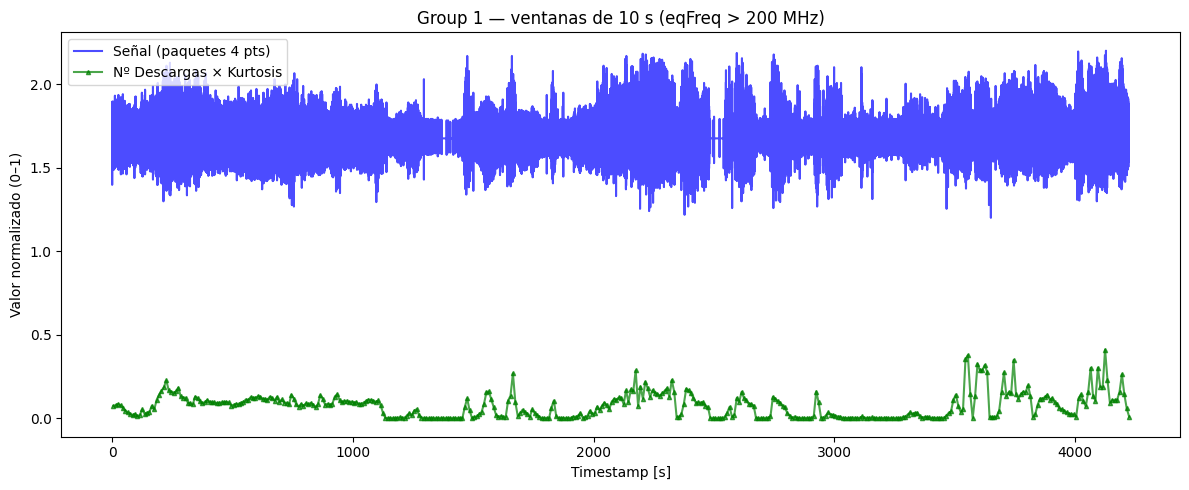